# Research Notebook
## Caleb Miller
## Date: Feb 23 - March 2, 2026

# 1: Experience
## Research activities this week

Wrote Python code to fit analytic temperature models to X-ray gas temperature profiles for several galaxy systems using data from the Humphrey et al. (2006) dataset.

Implemented and tested multiple temperature parameterizations from Humphrey et al. (2006), as well as a Vikhlinin et al. (2006) temperature profile.

Used optimization routines (`scipy.optimize.curve_fit`) to fit these models to the temperature data for several systems 

Compared the resulting temperature profiles using both chi-squared statistics and visual inspection of the fitted curves to determine which models best reproduce the observations.

Attended research group meetings to discuss model choices and fitting strategy.

## Motivation

The aim of this project is to study the hot X-ray–emitting gas in galaxy groups and use it to infer the underlying dark matter distribution under the assumption of hydrostatic equilibrium. In earlier discussions, we determined that an accurate analytic description of the gas temperature profile is essential for computing temperature gradients and using them in the hydrostatic equilibrium equation, since poorly constrained temperature models can introduce significant errors in the derived mass profiles. This week I focused on implementing and testing several analytic temperature models from Humphrey et al. (2006) and Vikhlinin et al. (2006), and evaluating how well they reproduce the observed X-ray temperature data. To do this, I used chi-squared tests to numerically compare different temperature parameterizations across the systems and visually inspected the resulting temperature profiles to identify any nonphysical fluctuations or oscillatory behavior in the models that might indicate a poor or unstable fit that weren't captured in the chi-squared tests.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.
## Temperature Profile Modeling

In this work, I modeled the radial gas temperature profile $T_{\mathrm{gas}}(r)$ for several galaxy systems using analytic temperature parameterizations from Humphrey et al. (2006) and Vikhlinin et al. (2006). These models are designed to reproduce the observed radial behavior of the X-ray gas temperature profile.

I wrote Python code to load X-ray temperature data for several galaxy systems from Humphrey et al. (2006) from an Excel spreadsheet and fit analytic temperature models to the data using `scipy.optimize.curve_fit`. The code reads the radial positions, temperatures, and measurement uncertainties for each system and then using this dataset, the code fits the temperature models presented in Humphrey et al. (2006) (Eqs. 3, 4, and 5), as well as a fixed $a$, $b$, $c$ temperature model from Vikhlinin et al. (2006). The goal is to determine which of these parameterizations best reproduces the observed X-ray temperature profiles.

After fitting the models, I computed the chi-squared statistic to quantify how well each model matches the observational data. The chi-squared statistic is given by

$$
\chi^2 = \sum_i \frac{\left(T_i - T_{\mathrm{model}}(r_i)\right)^2}{\sigma_i^2},
$$

where $T_i$ is the measured temperature at radius $r_i$, $\sigma_i$ is the measurement uncertainty, and $T_{\mathrm{model}}(r_i)$ is the predicted temperature from the analytic model. This statistic provides a quantitative measure of the goodness of fit for each temperature model.

In addition to comparing the chi-squared values, I also visually inspected the fitted temperature profiles. This step is important because some models can achieve relatively low chi-squared values while still producing nonphysical behavior, such as oscillations or unrealistic fluctuations in the temperature profile. By examining both the statistical fit and the physical behavior of the curves, I can better determine which temperature models are appropriate for further analysis.

The code loops over multiple galaxy systems, fits each analytic temperature model to the data, and produces plots showing the observational temperatures with error bars alongside the best-fit temperature curves. The chi-squared values for each model are also printed, allowing direct comparison between the models.

The resulting temperature fits and comparison plots were shared with the research group during our weekly meeting to discuss which parameterizations should be used in the subsequent mass modeling analysis.

---

## Analytic Temperature Models

Here are the three models in the **Humphrey et al.** paper that I used to fit temperature and radius data:

### Equation (3)

$$
T(r) = T_0 + T_1\left(1 + \frac{r}{r_c}\right)^{-p_e}.
$$

---

### Equation (4)

$$
T(r) =
(T_0 + T_1 x^{p_1})e^{-x^{p_e}}
+
(T_2 x^{p_2})(1 - e^{-x^{p_e}}),
$$

where

$$
x = \frac{r}{r_c}.
$$

---

### Equation (5)

$$
T(r) =
\frac{A}{A+B}
\left[T_0 + T_1\left(\frac{x_1}{1+x_1}\right)^{p_1}\right]
+
\frac{B}{A+B}
\left[T_2 + T_3(1+x_2)^{-p_2}\right],
$$

where

$$
x_1 = \frac{r}{r_{c1}}, \qquad
x_2 = \frac{r}{r_{c2}}, \qquad
A = (1 + r/r_{t1})^{-3\beta_1}, \qquad
B = \epsilon (1 + r/r_{t2})^{-3\beta_2}.
$$

Here, the radius r is fixed by the observational data. All remaining quantities appearing in the models — such as $T_0$, $T_1$, $T_2$, $r_c$, $p_1$, $p_2$, $p_e$, and other scale parameters — are treated as free parameters and are determined by fitting the model to the X-ray temperature data.

---

In addition to the Humphrey models, I also tested a temperature model from **Vikhlinin et al. (2006)** with fixed parameters $a=0$, $b=2$, and $c=0.6$. The resulting equation is:

$$
T(r) = T_0 \, t_{\mathrm{cool}}(r) \, t_{\mathrm{outer}}(r).
$$

where

$$
t_{\mathrm{outer}}(r) =
\left[1 + \left(\frac{r}{r_t}\right)^2\right]^{-0.3}, \qquad
t_{\mathrm{cool}}(r) =
\frac{x + T_{\min}/T_0}{x + 1},
\qquad
x = \left(\frac{r}{r_{\mathrm{cool}}}\right)^{a_{\mathrm{cool}}}.
$$

Here, the radius $r$ is fixed by the observational data. The remaining quantities appearing in the model — such as $T_0$, $r_t$, $r_{\mathrm{cool}}$, $a_{\mathrm{cool}}$, and $T_{\min}/T_0$ — are treated as free parameters and are determined by fitting the model to the X-ray temperature data.

---

# Code Used for Model Fitting

The Python code written this week loads the X-ray temperature data for several galaxy systems, fits multiple analytic temperature models to the data, and compares their performance using chi-squared statistics. The code uses `curve_fit` from the SciPy library to determine the best-fit parameters for each model. After fitting the models, the code evaluates the temperature profiles over the radial range of the data and produces plots showing the observed temperatures with error bars along with the best-fit curves.

This code below is specifically the code for the Eq. 3 model, but all the other models work in the same way. The equations and input parameters are the only aspects that change between the models.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

FILE = "Humphrey Xray.xlsx"

SYSTEMS = [
    "NGC720", "NGC1407", "NGC4125",
    "NGC4261", "NGC4472", "NGC4649", "NGC6482"
]

def T_eq3(r, T0, T1, rc, pe):
    r = np.maximum(np.asarray(r, float), 1e-12)
    rc = np.maximum(np.asarray(rc, float), 1e-12)
    x = r / rc
    return T0 + T1 * (1.0 + x) ** (-pe)

def chi2(y, yhat, sigma):
    return float(np.sum(((y - yhat) / sigma) ** 2))

xl = pd.ExcelFile(FILE)

for SYSTEM in SYSTEMS:
    print(f"\n===== {SYSTEM} =====")

    data = xl.parse(SYSTEM)
    data.columns = data.columns.str.strip()

    r = data["R (kpc)"].astype(float).to_numpy()
    T = data["Temp (keV)"].astype(float).to_numpy()
    eT = data["Error Temp (keV)"].astype(float).to_numpy()

    # initial guesses and bounds
    Tlo = float(np.percentile(T, 10))
    Thi = float(np.percentile(T, 90))
    dT = max(Thi - Tlo, 1e-3)
    rmin, rmax = float(r.min()), float(r.max())

    p0_3 = [
        max(Tlo, 0.0),                  # T0
        max(dT, 1e-3),                  # T1
        max(float(np.median(r)), 1e-3), # rc
        1.5                             # pe
    ]

    bounds_3 = (
        [0.0, 0.0, max(0.1*rmin, 1e-3), 0.05],
        [5.0*Thi, 5.0*dT, 10.0*rmax, 10.0]
    )

    # fit Eq. (3)
    p3, _ = curve_fit(
        T_eq3, r, T,
        sigma=eT,
        absolute_sigma=True,
        p0=p0_3,
        bounds=bounds_3,
        maxfev=300000,
    )

    # evaluate fit
    chi2_3 = chi2(T, T_eq3(r, *p3), eT)
    rplot = np.logspace(np.log10(max(rmin * 0.8, 1e-6)), np.log10(rmax * 1.1), 900)
    T3 = T_eq3(rplot, *p3)

    # print chi-squared
    print(f"  chi^2 = {chi2_3:.3f}")

    # plot data and fit
    plt.figure(figsize=(7, 5))
    plt.errorbar(r, T, yerr=eT, fmt="o", ms=4, capsize=2, label="Data")
    plt.plot(rplot, T3, lw=2, label="Eq. (3) fit")
    plt.xscale("log")
    plt.xlabel("R (kpc)")
    plt.ylabel("Temp (keV)")
    plt.title(f"{SYSTEM}: Temperature fit using Eq. (3)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3: So what? (What does it mean?)
## Describe your results

| Equation (3) model | Equation (4) model | Equation (5) model | Vikhlinin model |
|---------|----------|----------|----------|
| 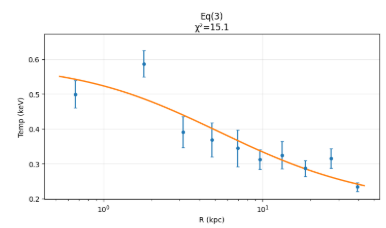 | 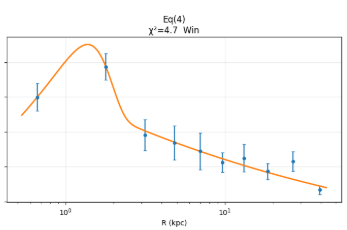 | 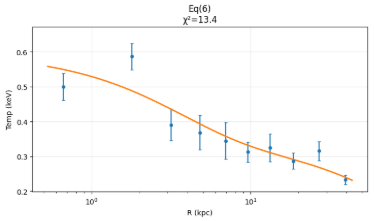 | 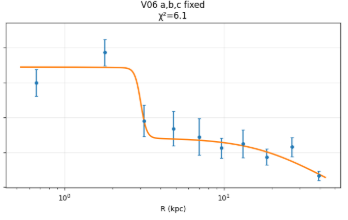 |

*Figure 1: Example best-fit gas temperature profiles for one of the galaxy systems using the analytic temperature models from Humphrey et al. (2006) (Equations 3, 4, and 5) and the Vikhlinin et al. (2006) temperature model. The curves are compared with the observed X-ray temperature measurements and their uncertainties.*

This week’s main result was the successful implementation and comparison of several analytic temperature models fitted to the X-ray temperature data for multiple galaxy systems from the Humphrey dataset. For each galaxy system, the code produced best-fit temperature profiles and calculated the corresponding chi-squared values for each model. These results allowed the models to be compared quantitatively while also allowing the fitted temperature profiles to be visually inspected.

Overall, the models were able to reproduce the general qualitative behavior of the observed temperature profiles, although some models performed better than others. Several different trends appeared in the data. First, there were systems where the temperature was high at small radii and gradually decreased as the distance from the center increased. Second, there were systems where the temperature was low near the center and increased with radius. Finally, some systems showed a profile where the temperature started at an intermediate value, decreased initially with radius, and then increased again at larger radii, producing a U-shaped temperature profile.

The simpler parameterization given by Equation (3) was generally able to capture the overall trend of temperature profiles that either increased or decreased monotonically with radius. However, it was not flexible enough to reproduce the U-shaped temperature behavior observed in some systems. In those cases, Equation (4) provided a better fit because its additional parameters allowed the model to capture both the inner decrease and the outer increase in temperature.

The more complex models, such as Equation (4), Equation (5), and the Vikhlinin et al. (2006) temperature model, provided additional freedom to reproduce the detailed shape of the temperature profile. However, the increased flexibility of these models could occasionally lead to unstable or oscillatory behavior in certain radial regions. For this reason, it was important to evaluate the fits using both the chi-squared statistic and visual inspection of the resulting temperature curves.

This activity represents an important step in the overall project because the gas temperature profile enters directly into the hydrostatic equilibrium equation used to infer the total gravitating mass of the galaxy systems. In particular, the temperature gradient with respect to radius is required when solving the hydrostatic equilibrium equation. As a result, it is important that the analytic temperature models used in the analysis are both stable and physically reasonable.

Overall, this work demonstrates that the analytic temperature models can be successfully implemented and fitted to the X-ray data. The comparison between models suggests that, for the Humphrey dataset, Equation (4) works best for the U-shaped temperature profiles because it has enough flexibility to match the observed behavior. In contrast, Equation (3) tends to perform better for profiles that increase or decrease monotonically with radius, since its simpler form avoids the nonphysical fluctuations in temperature that can appear in the more complex models.

# 4. Now what? (What's next?)
## Plan for the next week

This week I successfully implemented and compared several analytic temperature models and identified which parameterizations best reproduce the observed X-ray temperature profiles. The next step is to combine my temperature profile modeling code with my teammate Nikka’s gas density profile code in order to perform a full hydrostatic equilibrium analysis. Next week I will implement Markov Chain Monte Carlo (MCMC) simulations to jointly constrain the temperature and density model parameters and propagate their uncertainties into the inferred mass profiles. This will allow us to obtain more robust estimates of the total gravitating mass and dark matter distribution in the galaxy systems.

# 5. Bibliography

[1] A. Vikhlinin et al., Chandra Temperature Profiles for a Sample of Nearby Relaxed Galaxy Clusters, Astrophys. J. 640, 691 (2006), arXiv:astro-ph/0507092.

[2] P. J. Humphrey et al., A Chandra View of Dark Matter in Early-Type Galaxies, Astrophys. J. 646, 899 (2006), arXiv:astro-ph/0601301.